# 🌀 Diffusion Models - Part 1: Diffusing and Denoising MNIST

---

Name: Hamza Malik
Roll number: 26100060

# 🧪 Task 1: Implementing and Training a Diffusion Model on MNIST


### 🔧 Step 1: Install Required Libraries

Make sure the following libraries are installed: `torch`, `torchvision`, `matplotlib`, and `tqdm`.

Use the cell below to install them.

In [2]:
# Install any needed libraries

!pip install torch torchvision matplotlib tqdm --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 101.3 MB/s eta 0:00:00


In [3]:
# Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import math

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


cuda




## 📥 Load the MNIST Dataset


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to PyTorch tensors
])

mnist = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(mnist, batch_size=64, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 15.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.95MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.89MB/s]


### 🌫️ Step 2: Define the Noise Schedule

Implement your own beta noise schedule for a total of x number of timesteps. x is your own choice.

🧠 **Your task:**
- Decide whether to use a **linear** beta schedule or a **cosine** schedule.
- Implement the schedule accordingly.
- Compute `alphas` and `alpha_hats` for the diffusion process.

> This is your design choice. Think about how each schedule might impact the training.


In [ ]:
def create_linear_beta_schedule(total_timesteps, beta_start=0.0001, beta_end=0.02):
    beta_schedule = torch.linspace(beta_start, beta_end, total_timesteps, dtype=torch.float32)
    return beta_schedule

num_timesteps = 200
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

betas = create_linear_beta_schedule(num_timesteps).to(device)
alphas = (1.0 - betas).to(device)
alpha_hats = torch.cumprod(alphas, dim=0).to(device) # Can calculate directly on device
sqrt_alpha_hats = torch.sqrt(alpha_hats)
sqrt_one_minus_alpha_hats = torch.sqrt(1.0 - alpha_hats)

cuda


### 💨 Step 3: Implement Forward Diffusion Function

Create a function `forward_diffusion_sample(x_0, t)` that:

- Adds noise to the input image `x_0` at a given timestep `t`.
- Returns both the noised image and the added noise.

Use your computed `alpha_hats` to scale the input and noise correctly.


In [ ]:
def get_schedule_values(schedule_tensor, t, target_shape):
    batch_size = t.shape[0]
    selected_values = schedule_tensor[t]
    reshape_dims = (batch_size,) + (1,) * (len(target_shape) - 1)
    return selected_values.view(reshape_dims)


def forward_diffusion_sample(x_0, t, device="cpu"):
    noise = torch.randn_like(x_0, device=device)
    sqrt_alpha_hat_t = get_schedule_values(sqrt_alpha_hats.to(device), t, x_0.shape)
    sqrt_one_minus_alpha_hat_t = get_schedule_values(sqrt_one_minus_alpha_hats.to(device), t, x_0.shape)
    noisy_image = sqrt_alpha_hat_t * x_0.to(device) + sqrt_one_minus_alpha_hat_t * noise
    return noisy_image, noise


### 👁️ Step 4: Visualize the Diffusion Process

Pick a sample image from the dataset and visualize how it looks after applying noise at different timesteps (e.g. t = 0, 50, 100, 150, 199, ... x)



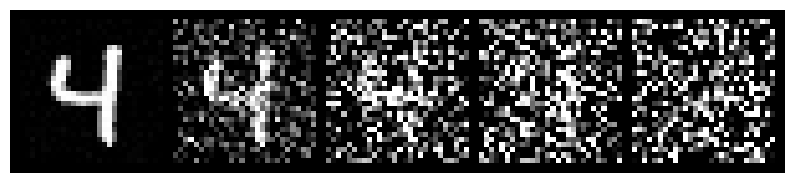

In [ ]:
# Visualize diffusion over timesteps
def show_image_grid(images):
    grid = make_grid(images, nrow=8)
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.show()

# Show progression of one image
x, _ = next(iter(dataloader))
x = x[:1]
timesteps = [ 1, 50, 100, 150, 199]

noised_images = []
for t in timesteps:
    t_batch = torch.tensor([t])
    noised, _ = forward_diffusion_sample(x, t_batch)
    noised_images.append(noised)

show_image_grid(torch.cat(noised_images, dim=0))


### 🧠 Step 5: Build the Denoising Model

Implement a U-Net style architecture to predict noise given a noisy image and a timestep `t`.


In [ ]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time.unsqueeze(1) * embeddings.unsqueeze(0)
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        if self.dim % 2 == 1:
             embeddings = F.pad(embeddings, (0, 1))
        return embeddings


class SimpleResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_channels)
        self.act1 = nn.SiLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.act2 = nn.SiLU()
        self.time_mlp = nn.Linear(time_emb_dim, out_channels)
        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.residual_conv = nn.Identity()

    def forward(self, x, t_emb):
        residual = self.residual_conv(x)
        out = self.conv1(x)
        out = self.norm1(out)
        out = self.act1(out)
        time_bias = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        out = out + time_bias
        out = self.conv2(out)
        out = self.norm2(out)
        out = self.act2(out)
        return out + residual


class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        self.res_block = SimpleResidualBlock(in_channels, out_channels, time_emb_dim)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x, t_emb):
        x = self.res_block(x, t_emb)
        pooled_x = self.pool(x)
        return x, pooled_x

class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, time_emb_dim):
        super().__init__()
        self.up_conv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.res_block = SimpleResidualBlock(out_channels + skip_channels, out_channels, time_emb_dim)

    def forward(self, x, skip_x, t_emb):
        x = self.up_conv(x)
        combined_x = torch.cat([x, skip_x], dim=1)
        x = self.res_block(combined_x, t_emb)
        return x



class SimpleUNet(nn.Module):
    def __init__(self, image_channels=1, time_emb_dim=128, base_channels=64):
        super().__init__()
        self.image_channels = image_channels
        self.time_emb_dim = time_emb_dim
        channels = [base_channels, base_channels*2, base_channels*4]

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU()
        )

        self.initial_conv = nn.Conv2d(image_channels, channels[0], kernel_size=3, padding=1)
        self.down1 = DownBlock(channels[0], channels[1], time_emb_dim)
        self.down2 = DownBlock(channels[1], channels[2], time_emb_dim)
        self.bottleneck = SimpleResidualBlock(channels[2], channels[2], time_emb_dim)
        self.up1 = UpBlock(channels[2], channels[2], channels[1], time_emb_dim)
        self.up2 = UpBlock(channels[1], channels[1], channels[0], time_emb_dim)
        self.final_conv = nn.Conv2d(channels[0], image_channels, kernel_size=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        x = self.initial_conv(x)
        skip1_out, x = self.down1(x, t_emb)
        skip2_out, x = self.down2(x, t_emb)
        x = self.bottleneck(x, t_emb)
        x = self.up1(x, skip2_out, t_emb)
        x = self.up2(x, skip1_out, t_emb)
        predicted_noise = self.final_conv(x)
        return predicted_noise

### 🏋️ Step 6: Train the Denoiser

- Instantiate your model and move it to the correct device (`cuda` if available).
- Define an optimizer (e.g., Adam) and a suitable learning rate.
- Write a training loop for the denoiser.

Show the loss at the end of each epoch.

Plot the loss curve

Epoch 1/10:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1/10 - Average Loss: 0.0669


Epoch 2/10:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2/10 - Average Loss: 0.0407


Epoch 3/10:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 8/10 - Average Loss: 0.0331


Epoch 9/10:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 9/10 - Average Loss: 0.0330


Epoch 10/10:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 10/10 - Average Loss: 0.0325


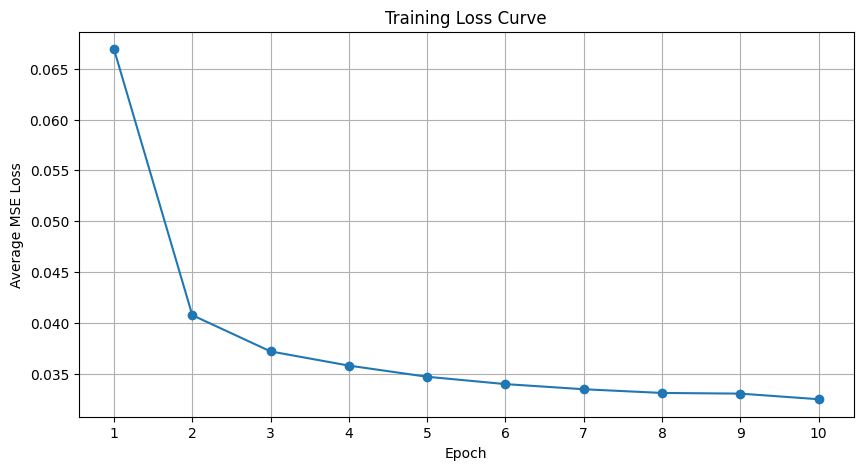

Model weights saved.


In [ ]:
model = SimpleUNet(image_channels=1, time_emb_dim=128, base_channels=64).to(device)
learning_rate = 1e-4
num_epochs = 10

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()
epoch_losses = []
for epoch in range(num_epochs):
    model.train()
    total_epoch_loss = 0.0
    num_batches = 0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

    for batch_idx, (x_0_batch, _) in enumerate(progress_bar):
            x_0_batch = x_0_batch.to(device)
            current_batch_size = x_0_batch.shape[0]
            t_batch = torch.randint(0, num_timesteps, (current_batch_size,), device=device, dtype=torch.long)
            x_t_batch, target_noise = forward_diffusion_sample(x_0_batch, t_batch, device=device)
            optimizer.zero_grad()
            predicted_noise = model(x_t_batch, t_batch)
            loss = loss_fn(predicted_noise, target_noise)
            loss.backward()
            optimizer.step()
            total_epoch_loss += loss.item()
            num_batches += 1
            progress_bar.set_postfix(batch_loss=f"{loss.item():.4f}")


    average_epoch_loss = total_epoch_loss / num_batches
    epoch_losses.append(average_epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Average Loss: {average_epoch_loss:.4f}")


plt.figure(figsize=(10, 5))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o', linestyle='-')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Average MSE Loss')
plt.grid(True)
plt.xticks(range(1, len(epoch_losses) + 1))
plt.show()
torch.save(model.state_dict(), 'simple_unet_mnist_weights_final.pth')
print("Model weights saved.")

### ✨ Step 7: Generate a Sample by Reversing Diffusion

Plot the final denoised image.


  0%|          | 0/200 [00:00<?, ?it/s]

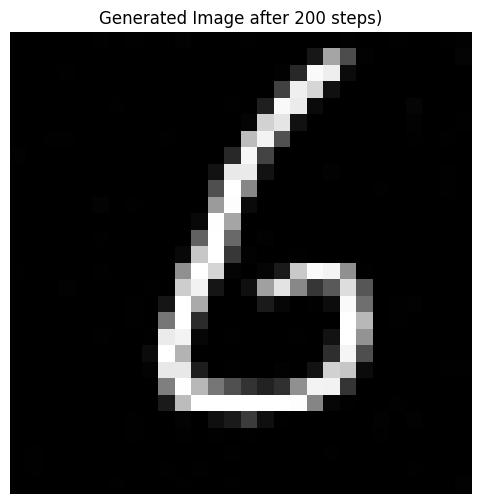

In [ ]:
@torch.no_grad()
def reverse_diffusion_sample(model, shape, device, num_timesteps, schedule_tensors):
    img = torch.randn(shape, device=device)
    betas = schedule_tensors['betas']
    alphas = schedule_tensors['alphas']
    sqrt_one_minus_alpha_hats = schedule_tensors['sqrt_one_minus_alpha_hats']

    model.eval()
    for t in tqdm(range(num_timesteps - 1, -1, -1)):
        t_tensor = torch.full((shape[0],), t, device=device, dtype=torch.long)
        beta_t = get_schedule_values(betas, t_tensor, img.shape)
        alpha_t = get_schedule_values(alphas, t_tensor, img.shape)
        sqrt_one_minus_alpha_hat_t = get_schedule_values(sqrt_one_minus_alpha_hats, t_tensor, img.shape)
        sqrt_beta_t = torch.sqrt(beta_t)
        predicted_noise = model(img, t_tensor)
        term1 = 1.0 / torch.sqrt(alpha_t)
        term2 = beta_t / sqrt_one_minus_alpha_hat_t
        mean_t_minus_1 = term1 * (img - term2 * predicted_noise)
        noise = torch.randn_like(img) if t > 0 else torch.zeros_like(img)
        img = mean_t_minus_1 + sqrt_beta_t * noise

    return img



output_shape = (1, 1, 28, 28)
schedule_dict = {
    'betas': betas,
    'alphas': alphas,
    'alpha_hats': alpha_hats,
    'sqrt_one_minus_alpha_hats': sqrt_one_minus_alpha_hats
}
generated_image = reverse_diffusion_sample(model, output_shape, device, num_timesteps, schedule_dict)

plt.figure(figsize=(6, 6))
final_image_cpu = generated_image.clamp(0, 1).squeeze(0).squeeze(0).cpu().numpy()

plt.imshow(final_image_cpu, cmap='gray')
plt.title(f"Generated Image after {num_timesteps} steps)")
plt.axis('off')
plt.show()

## 🧠 Analytical Questions

Answer the following questions in a separate Markdown cell:

1. Prove that the forward process is a Markov chain. What assumptions are being made?
2. Derive the expression for the mean and variance of the noisy image at timestep \( t \).
3. How does the choice of the beta schedule affect the learning process and final image quality?
4. What would happen if we used too few timesteps (e.g., T = 20)?

ANS 1:

The forward diffusion process defines each step as:

$$
q(x_t \mid x_{t-1}) = \mathcal{N}(x_t;\, \sqrt{\alpha_t}\,x_{t-1},\,\beta_t I),
\quad t=1,\dots,T,
$$

where \( x_0 \) is sampled from the data distribution.

The full joint distribution factorizes as:

$$
q(x_{0:T}) = q(x_0)\prod_{t=1}^T q(x_t \mid x_{t-1}).
$$

Thus, the conditional simplifies to:

$$
q(x_t \mid x_{0:t-1}) = q(x_t \mid x_{t-1}),
$$

which shows the Markov property: each \( x_t \) depends only on \( x_{t-1} \) and not on earlier variables.

**Assumption:**
-  the noise terms are independent and Gaussian across time steps.



ANS 2:

The update rule for the forward process is:

$$
x_t = \sqrt{\alpha_t}\,x_{t-1} + \sqrt{\beta_t}\,\epsilon_t,
\quad \epsilon_t \sim \mathcal{N}(0,I).
$$

Unrolling recursively back to \( x_0 \):

$$
x_t = \sqrt{\bar\alpha_t}\,x_0 + \sum_{i=1}^t \left( \sqrt{\beta_i}\,\epsilon_i \prod_{j=i+1}^t \sqrt{\alpha_j} \right),
$$

where:

$$
\bar\alpha_t = \prod_{i=1}^t \alpha_i.
$$

Since each \( \epsilon_i \) has zero mean and they are independent, the mean and variance are:

- **Mean:**

$$
\mathbb{E}[x_t \mid x_0] = \sqrt{\bar\alpha_t}\,x_0
$$

- **Variance:**

$$
\mathrm{Var}[x_t \mid x_0] = (1 - \bar\alpha_t) I
$$

Thus, the conditional distribution is:

$$
x_t \mid x_0 \sim \mathcal{N}\left( \sqrt{\bar\alpha_t}\,x_0,\ (1-\bar\alpha_t)I \right).
$$


ANS 3:


The beta schedule \( \beta_t \) controls how much noise is added at each step:

- **linear schedule**:
  - Noise is injected slowly.
  - Each denoising step is mild and easier to learn.
  - Requires a large number of steps \( T \), leading to slower sampling.

- **Cosine schedule**:
  - Smaller noise at the start and end, larger in the middle.
  - Balances training stability with fewer steps.
  - Improves sample quality with less computational cost compared to linear.

The choice of schedule affects the signal-to-noise ratio (SNR) at each timestep, the difficulty of reverse modeling, and overall training and inference efficiency.

ANS 4:

Using a small number of timesteps has significant drawbacks. Each reverse step must remove a large amount of noise and denoising becomes very difficult, leading to blurry, incoherent, or unrealistic samples. Even with careful schedule tuning, fewer timesteps limit generation quality.
Thus, a very low number of steps fundamentally worsens sample fidelity and training stability.


---
# 🧪 Task 2: Class-Conditional Diffusion on MNIST


### 🧠 Step 1: Define the Conditional Denoising Model

You now need to build a class-conditional version of your denoising U-Net from Task 1.

Requirements:
- Add a learnable **class embedding layer** (`nn.Embedding`) for MNIST digit classes (0–9).
- Concatenate the **time embedding** and **class embedding**.
- Use the combined embedding.




In [ ]:
class ConditionalUNet(nn.Module):
    def __init__(self,
                 image_channels=1,
                 num_classes=10,
                 class_emb_dim=64,
                 time_emb_dim=128,
                 base_channels=64):
        super().__init__()
        self.image_channels = image_channels
        self.num_classes = num_classes
        self.class_emb_dim = class_emb_dim
        self.time_emb_dim = time_emb_dim
        channels = [base_channels, base_channels*2, base_channels*4]
        self.time_embed = SinusoidalPositionEmbeddings(time_emb_dim)

        self.class_embed = nn.Embedding(num_classes, class_emb_dim)
        combined_emb_input_dim = time_emb_dim + class_emb_dim
        self.embedding_mlp = nn.Sequential(
           nn.Linear(combined_emb_input_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )
        self.initial_conv = nn.Conv2d(image_channels, channels[0], kernel_size=3, padding=1)
        self.down1 = DownBlock(channels[0], channels[1], time_emb_dim)
        self.down2 = DownBlock(channels[1], channels[2], time_emb_dim)
        self.bottleneck = SimpleResidualBlock(channels[2], channels[2], time_emb_dim)
        self.up1 = UpBlock(channels[2], channels[2], channels[1], time_emb_dim)
        self.up2 = UpBlock(channels[1], channels[1], channels[0], time_emb_dim)
        self.final_conv = nn.Conv2d(channels[0], image_channels, kernel_size=1)

    def forward(self, x, t, labels):
        t_emb = self.time_embed(t)
        c_emb = self.class_embed(labels.long())
        combined_emb = torch.cat([t_emb, c_emb], dim=-1)
        proj_emb = self.embedding_mlp(combined_emb)
        h = self.initial_conv(x)
        skip1_out, h = self.down1(h, proj_emb)
        skip2_out, h = self.down2(h, proj_emb)
        h = self.bottleneck(h, proj_emb)
        h = self.up1(h, skip2_out, proj_emb)
        h = self.up2(h, skip1_out, proj_emb)
        predicted_noise = self.final_conv(h)

        return predicted_noise

### 🏋️ Step 2: Train the Conditional Model

Write a training loop similar to Task 1, but now pass class labels (`y`) along with the timestep (`t`) to the model.

🔁 Everything else (e.g., noise sampling, loss calculation) remains the same as Task 1.


Epoch 1/10:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2/10:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 3/10:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 4/10:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 5/10:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 6/10:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 7/10:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 8/10:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 9/10:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 10/10:   0%|          | 0/938 [00:00<?, ?it/s]

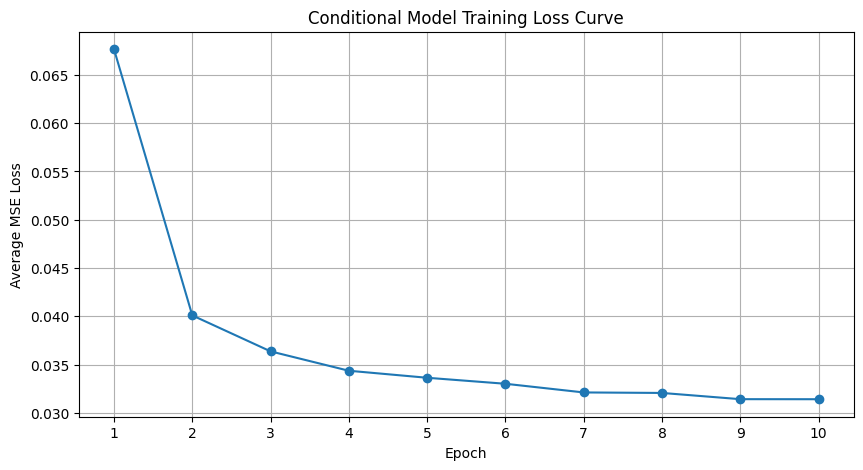

Conditional model weights saved.


In [ ]:
conditional_model = ConditionalUNet( image_channels=1,num_classes=10,class_emb_dim=64,time_emb_dim=128,base_channels=64).to(device)
learning_rate = 1e-4
num_epochs = 10
optimizer = torch.optim.Adam(conditional_model.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

conditional_epoch_losses = []
for epoch in range(num_epochs):
    conditional_model.train()
    total_epoch_loss = 0.0
    num_batches = 0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    for batch_idx, (x_0_batch, y_batch) in enumerate(progress_bar):
            x_0_batch = x_0_batch.to(device)
            y_batch = y_batch.to(device)
            current_batch_size = x_0_batch.shape[0]
            t_batch = torch.randint(0, num_timesteps, (current_batch_size,), device=device, dtype=torch.long)
            x_t_batch, target_noise = forward_diffusion_sample(x_0_batch, t_batch, device=device)
            optimizer.zero_grad()
            predicted_noise = conditional_model(x_t_batch, t_batch, y_batch)
            loss = loss_fn(predicted_noise, target_noise)
            loss.backward()
            optimizer.step()
            total_epoch_loss += loss.item()
            num_batches += 1
            progress_bar.set_postfix(batch_loss=f"{loss.item():.4f}")


    average_epoch_loss = total_epoch_loss / num_batches
    conditional_epoch_losses.append(average_epoch_loss)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(conditional_epoch_losses) + 1), conditional_epoch_losses, marker='o', linestyle='-')
plt.title('Conditional Model Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Average MSE Loss')
plt.grid(True)
plt.xticks(range(1, len(conditional_epoch_losses) + 1))
plt.show()


torch.save(conditional_model.state_dict(), 'conditional_unet_mnist_weights.pth')
print("Conditional model weights saved.")

### ✨ Step 3: Sample Class-Conditioned Images

Write a sampling function to generate images conditioned on a class label.

🔁 Use your reverse diffusion process from Task 1.
- Only difference: now pass the label `y` to the model.


  0%|          | 0/200 [00:00<?, ?it/s]

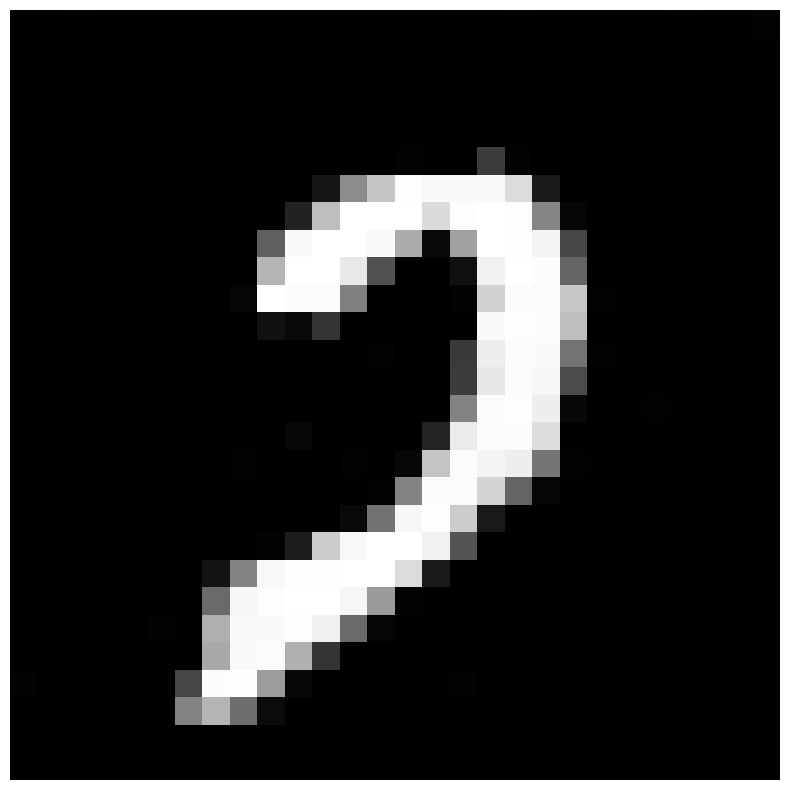

In [ ]:
@torch.no_grad()
def conditional_reverse_diffusion_sample(model,n_samples,target_label,img_shape,device,num_timesteps,schedule_tensors):

    labels = torch.full((n_samples,), target_label, device=device, dtype=torch.long)
    img = torch.randn((n_samples,) + img_shape, device=device)
    betas = schedule_tensors['betas']
    alphas = schedule_tensors['alphas']
    sqrt_one_minus_alpha_hats = schedule_tensors['sqrt_one_minus_alpha_hats']
    model.eval()
    for t in tqdm(range(num_timesteps - 1, -1, -1)):
        t_tensor = torch.full((n_samples,), t, device=device, dtype=torch.long)
        beta_t = get_schedule_values(betas, t_tensor, img.shape)
        alpha_t = get_schedule_values(alphas, t_tensor, img.shape)
        sqrt_one_minus_alpha_hat_t = get_schedule_values(sqrt_one_minus_alpha_hats, t_tensor, img.shape)
        sqrt_beta_t = torch.sqrt(beta_t)
        predicted_noise = model(img, t_tensor, labels)
        term1 = 1.0 / torch.sqrt(alpha_t)
        term2 = beta_t / sqrt_one_minus_alpha_hat_t
        mean_t_minus_1 = term1 * (img - term2 * predicted_noise)
        noise = torch.randn_like(img) if t > 0 else torch.zeros_like(img)
        img = mean_t_minus_1 + sqrt_beta_t * noise

    return img

label_to_generate = 7
num_samples_to_generate = 1
image_shape_tuple = (1, 28, 28)
schedule_dict = {
    'betas': betas.to(device),
    'alphas': alphas.to(device),
    'alpha_hats': alpha_hats.to(device),
    'sqrt_one_minus_alpha_hats': sqrt_one_minus_alpha_hats.to(device)
}
generated_images = conditional_reverse_diffusion_sample(conditional_model,n_samples=num_samples_to_generate, target_label=label_to_generate, img_shape=image_shape_tuple, device=device, num_timesteps=num_timesteps, schedule_tensors=schedule_dict)
show_image_grid(generated_images.clamp(0, 1))




### 🎨 Step 4: Visualize Class-Conditioned Samples

Generate and plot 1 image for each digit (0–9) using your class-conditional sampling function.
- Use `matplotlib` and display all results in a grid.
- Add titles showing the digit each image was conditioned on.


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

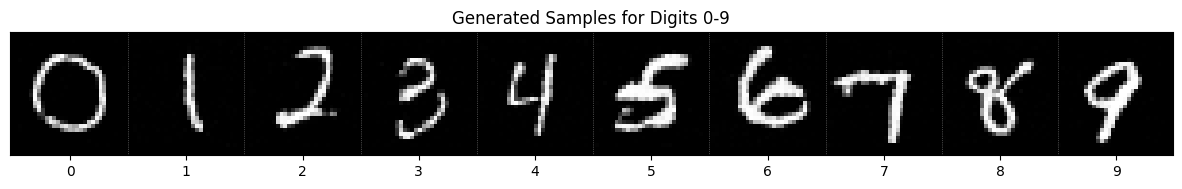

In [ ]:
num_classes_to_visualize = 10
samples_per_class = 1
image_shape_tuple = (1, 28, 28)
all_digit_samples = []
schedule_dict = {
    'betas': betas.to(device),
    'alphas': alphas.to(device),
    'alpha_hats': alpha_hats.to(device),
    'sqrt_one_minus_alpha_hats': sqrt_one_minus_alpha_hats.to(device)
}

for digit in range(10):
    generated_sample = conditional_reverse_diffusion_sample(
        model=conditional_model,
        n_samples=samples_per_class,
        target_label=digit,
        img_shape=image_shape_tuple,
        device=device,
        num_timesteps=num_timesteps,
        schedule_tensors=schedule_dict
    )
    all_digit_samples.append(generated_sample)


final_batch = torch.cat(all_digit_samples, dim=0)
final_batch_clamped = final_batch.clamp(0, 1)
grid = make_grid(final_batch_clamped, nrow=num_classes_to_visualize, padding=2)

plt.figure(figsize=(15, 3))
plt.imshow(grid.cpu().permute(1, 2, 0))
plt.title("Generated Samples for Digits 0-9")
tick_positions = [(grid.shape[2] / num_classes_to_visualize) * (i + 0.5) for i in range(num_classes_to_visualize)]
plt.xticks(ticks=tick_positions, labels=range(num_classes_to_visualize))
plt.yticks([])
for i in range(1, num_classes_to_visualize):
      plt.axvline(x=(grid.shape[2] / num_classes_to_visualize) * i, color='gray', linestyle=':', linewidth=0.5)

plt.show()



---
# 🧪 Task 3: Text-Guided Image Generation using CLIP + Diffusion

### 🔎 Step 1: Load a Pretrained CLIP Model

Use OpenAI’s CLIP model to obtain a text embedding from a given prompt.

🔍 Your task:
- Find and install the CLIP library.
- Load a pretrained CLIP model of your choice.
- Write a function to get normalized CLIP text embeddings from a prompt.

💡 Hint: Look into the `clip` module and `clip.tokenize`, `clip.load`, and `clip.encode_text`.


In [ ]:
import clip
available_models = clip.available_models()
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()

@torch.no_grad()
def get_clip_text_embedding(prompt: str, clip_model, device):
        text_tokens = clip.tokenize([prompt]).to(device)
        text_embedding = clip_model.encode_text(text_tokens)
        norm = text_embedding.norm(dim=-1, keepdim=True)
        normalized_embedding = text_embedding / norm
        return normalized_embedding

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


100%|███████████████████████████████████████| 338M/338M [00:06<00:00, 55.5MiB/s]


### 🖼️ Step 2: Implement CLIP-Guided Loss

Create a function that:
- Resizes the generated image to 224x224.
- Converts it to 3 channels.
- Passes it through CLIP’s image encoder.
- Calculates the **cosine similarity** with the given text embedding.
- Returns the CLIP loss: `1 - cosine_similarity`.

📌 This loss will be used to guide your diffusion sampling.


In [ ]:
clip_normalizer = transforms.Normalize(mean= [0.48145466, 0.4578275, 0.40821073], std= [0.26862954, 0.26130258, 0.27577711])

def preprocess_image_for_clip(image_batch: torch.Tensor, target_size: int = 224) -> torch.Tensor:
    image_batch = image_batch.repeat(1, 3, 1, 1)
    image_batch_resized = F.interpolate(image_batch,size=target_size,mode='bicubic',align_corners=False,antialias=True)
    image_batch_normalized = clip_normalizer(image_batch_resized.clamp(0, 1))
    return image_batch_normalized

def calculate_clip_guidance_loss(generated_image: torch.Tensor,target_text_embedding: torch.Tensor,clip_model,device: str) -> torch.Tensor:
    image_for_clip = preprocess_image_for_clip(generated_image.to(device))
    image_embedding = clip_model.encode_image(image_for_clip)
    image_embedding_norm = image_embedding / image_embedding.norm(dim=-1, keepdim=True)
    target_text_embedding = target_text_embedding.to(device)
    target_text_embedding = target_text_embedding.repeat(image_embedding_norm.shape[0], 1)
    cosine_sim = (image_embedding_norm * target_text_embedding).sum(dim=-1)
    clip_loss = 1.0 - cosine_sim
    return clip_loss.mean()


### 🔁 Step 3: Implement Text-Guided Sampling

You will now generate an image **guided by a text prompt** using the reverse diffusion process.

🔧 Modify the DDPM sampling loop:
- At each step, predict noise using your model from task 1.
- Add a CLIP-guided loss term.
- Backpropagate through the generated image and adjust it with the CLIP gradient.

🧠 Use your diffusion schedule (`alpha`, `alpha_hat`, `beta`) from previous tasks.


In [ ]:
unconditional_denoise_model = model
unconditional_denoise_model.eval()
clip_model.eval()
def clip_guided_sampling_step(x_t: torch.Tensor,t: int,  text_embedding: torch.Tensor, denoise_model,clip_model,guidance_scale: float,schedule_tensors: dict,device: str) -> torch.Tensor:
    x_t = x_t.detach().requires_grad_(True)
    clip_loss = calculate_clip_guidance_loss(x_t, text_embedding, clip_model, device)
    grad = torch.autograd.grad(clip_loss, x_t)[0]
    with torch.no_grad():
        t_tensor = torch.full((x_t.shape[0],), t, device=device, dtype=torch.long)
        pred_noise_unconditional = denoise_model(x_t.detach(), t_tensor)
        sqrt_one_minus_alpha_hat_t = get_schedule_values(schedule_tensors['sqrt_one_minus_alpha_hats'], t_tensor, x_t.shape)
        beta_t = get_schedule_values(schedule_tensors['betas'], t_tensor, x_t.shape)
        alpha_t = get_schedule_values(schedule_tensors['alphas'], t_tensor, x_t.shape)
        sqrt_beta_t = torch.sqrt(beta_t)
        effective_noise = pred_noise_unconditional - sqrt_one_minus_alpha_hat_t * guidance_scale * grad.detach()
        term1 = 1.0 / torch.sqrt(alpha_t)
        term2 = beta_t / sqrt_one_minus_alpha_hat_t
        mean_t_minus_1 = term1 * (x_t.detach() - term2 * effective_noise)
        noise_z = torch.randn_like(x_t) if t > 0 else torch.zeros_like(x_t)
        x_t_minus_1 = mean_t_minus_1 + sqrt_beta_t * noise_z

    return x_t_minus_1


def clip_guided_reverse_diffusion(denoise_model, clip_model, text_embedding,shape,  guidance_scale,  device, num_timesteps, schedule_tensors):
    denoise_model.eval()
    clip_model.eval()
    img = torch.randn(shape, device=device)
    for t in tqdm(range(num_timesteps - 1, -1, -1)):
        img = clip_guided_sampling_step(x_t=img,t=t,text_embedding=text_embedding,denoise_model=denoise_model,clip_model=clip_model,guidance_scale=guidance_scale,schedule_tensors=schedule_tensors,device=device
)
    return img


### 🎯 Step 4: Generate Images from Prompts

Generate one image each for the following prompts:

- `"two"`
- `"five"`
- `"nine"`

Use your `text_guided_sample` function and visualize the results using `matplotlib`.

🎨 Title each image with the prompt used.


  0%|          | 0/200 [00:00<?, ?it/s]

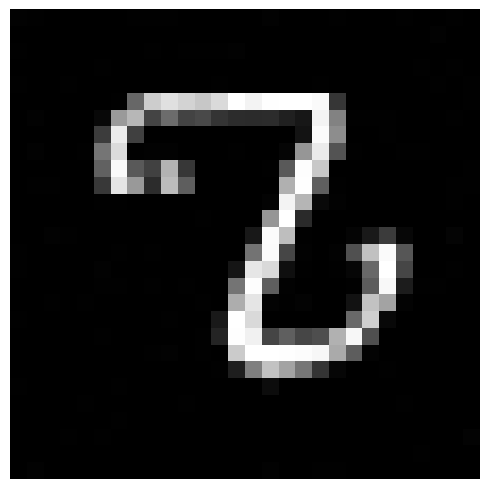

In [ ]:
prompt="two"
num_images_to_generate =1
samples_per_prompt = 1
image_shape_tuple = (1, 28, 28)
guidance_strength = 100
generated_images_list = []
target_embedding = get_clip_text_embedding(prompt, clip_model, device)

generated_image = clip_guided_reverse_diffusion(denoise_model=unconditional_denoise_model,clip_model=clip_model,text_embedding=target_embedding,shape=(samples_per_prompt,) + image_shape_tuple,guidance_scale=guidance_strength, device=device,num_timesteps=num_timesteps,schedule_tensors=schedule_dict)
generated_images_list.append(generated_image)

num_generated = len(generated_images_list)
fig, axes = plt.subplots(1, num_generated, figsize=(5 * num_generated, 5.5))
if num_generated == 1:
    axes = [axes]

for i in range(num_generated):
    img_tensor = generated_images_list[i]
    img_display = img_tensor.clamp(0, 1).squeeze(0).squeeze(0).cpu().numpy()
    ax = axes[i]
    ax.imshow(img_display, cmap='gray')
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



  0%|          | 0/200 [00:00<?, ?it/s]

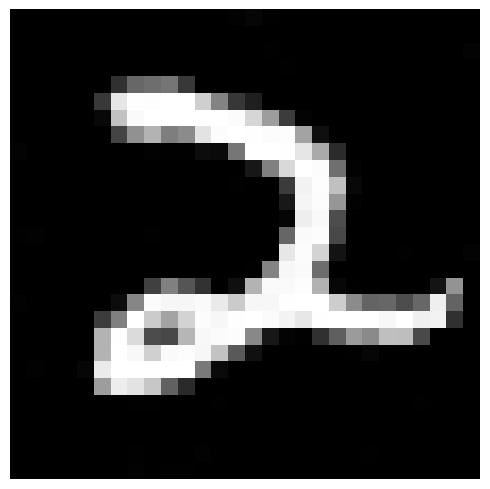

In [ ]:

prompt="number two"
num_images_to_generate =1
samples_per_prompt = 1
image_shape_tuple = (1, 28, 28)
guidance_strength = 100
generated_images_list = []
target_embedding = get_clip_text_embedding(prompt, clip_model, device)

generated_image = clip_guided_reverse_diffusion(denoise_model=unconditional_denoise_model,clip_model=clip_model,text_embedding=target_embedding,shape=(samples_per_prompt,) + image_shape_tuple,guidance_scale=guidance_strength, device=device,num_timesteps=num_timesteps,schedule_tensors=schedule_dict)
generated_images_list.append(generated_image)

num_generated = len(generated_images_list)
fig, axes = plt.subplots(1, num_generated, figsize=(5 * num_generated, 5.5))
if num_generated == 1:
    axes = [axes]

for i in range(num_generated):
    img_tensor = generated_images_list[i]
    img_display = img_tensor.clamp(0, 1).squeeze(0).squeeze(0).cpu().numpy()
    ax = axes[i]
    ax.imshow(img_display, cmap='gray')
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



  0%|          | 0/200 [00:00<?, ?it/s]

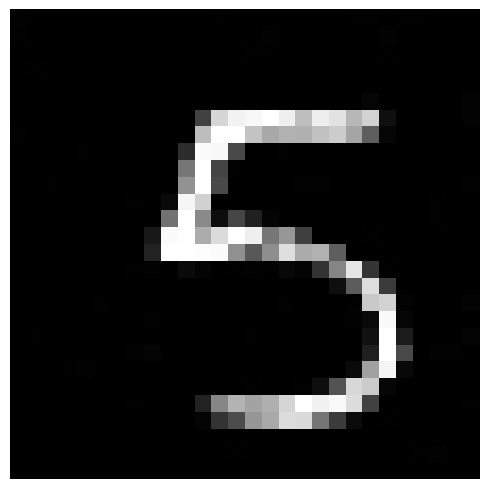

In [ ]:

prompt="five"
num_images_to_generate =1
samples_per_prompt = 1
image_shape_tuple = (1, 28, 28)
guidance_strength = 100
generated_images_list = []
target_embedding = get_clip_text_embedding(prompt, clip_model, device)

generated_image = clip_guided_reverse_diffusion(denoise_model=unconditional_denoise_model,clip_model=clip_model,text_embedding=target_embedding,shape=(samples_per_prompt,) + image_shape_tuple,guidance_scale=guidance_strength, device=device,num_timesteps=num_timesteps,schedule_tensors=schedule_dict)
generated_images_list.append(generated_image)

num_generated = len(generated_images_list)
fig, axes = plt.subplots(1, num_generated, figsize=(5 * num_generated, 5.5))
if num_generated == 1:
    axes = [axes]

for i in range(num_generated):
    img_tensor = generated_images_list[i]
    img_display = img_tensor.clamp(0, 1).squeeze(0).squeeze(0).cpu().numpy()
    ax = axes[i]
    ax.imshow(img_display, cmap='gray')
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

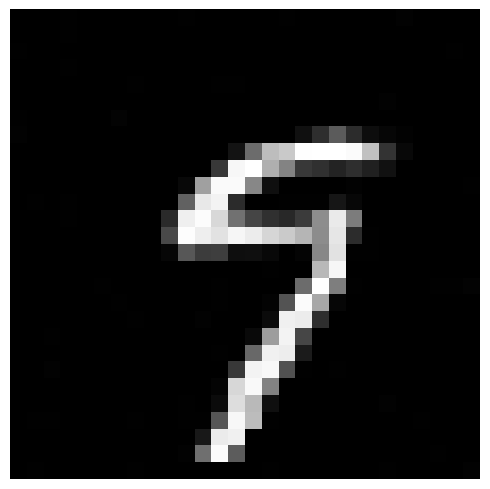

In [ ]:

prompt="nine"
num_images_to_generate =1
samples_per_prompt = 1
image_shape_tuple = (1, 28, 28)
guidance_strength = 100
generated_images_list = []
target_embedding = get_clip_text_embedding(prompt, clip_model, device)

generated_image = clip_guided_reverse_diffusion(denoise_model=unconditional_denoise_model,clip_model=clip_model,text_embedding=target_embedding,shape=(samples_per_prompt,) + image_shape_tuple,guidance_scale=guidance_strength, device=device,num_timesteps=num_timesteps,schedule_tensors=schedule_dict)
generated_images_list.append(generated_image)

num_generated = len(generated_images_list)
fig, axes = plt.subplots(1, num_generated, figsize=(5 * num_generated, 5.5))
if num_generated == 1:
    axes = [axes]

for i in range(num_generated):
    img_tensor = generated_images_list[i]
    img_display = img_tensor.clamp(0, 1).squeeze(0).squeeze(0).cpu().numpy()
    ax = axes[i]
    ax.imshow(img_display, cmap='gray')
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

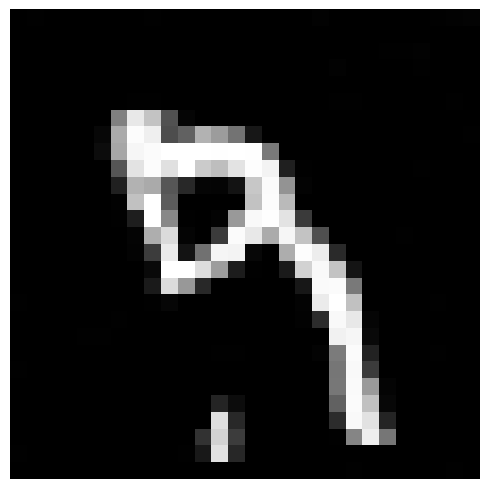

In [ ]:

prompt="dog"
num_images_to_generate =1
samples_per_prompt = 1
image_shape_tuple = (1, 28, 28)
guidance_strength = 100
generated_images_list = []
target_embedding = get_clip_text_embedding(prompt, clip_model, device)

generated_image = clip_guided_reverse_diffusion(denoise_model=unconditional_denoise_model,clip_model=clip_model,text_embedding=target_embedding,shape=(samples_per_prompt,) + image_shape_tuple,guidance_scale=guidance_strength, device=device,num_timesteps=num_timesteps,schedule_tensors=schedule_dict)
generated_images_list.append(generated_image)

num_generated = len(generated_images_list)
fig, axes = plt.subplots(1, num_generated, figsize=(5 * num_generated, 5.5))
if num_generated == 1:
    axes = [axes]

for i in range(num_generated):
    img_tensor = generated_images_list[i]
    img_display = img_tensor.clamp(0, 1).squeeze(0).squeeze(0).cpu().numpy()
    ax = axes[i]
    ax.imshow(img_display, cmap='gray')
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 🔍 Questions

1. Do the outputs look like the digits you prompted?

Ans: alhmadullillah, yes the outputs look like the digits I prompted.

2. How sensitive is the model to different wording (e.g., "number two" vs. "two")?

Ans: The model appears to be fairly robust to minor changes in phrasing. Whether the prompt was "number two" or just "two," it still generated the digit 2. slight diffrences such as  "number two" generating a slightly bettter looking 2 is probably just randomness.

3. What would happen if you guide the image with a totally unrelated prompt (e.g., "dog")?

Ans:the model produces random outputs . it generates noisy or meaningless images, or sometimes outputs vaguely digit-like patterns.


